In [16]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib widget

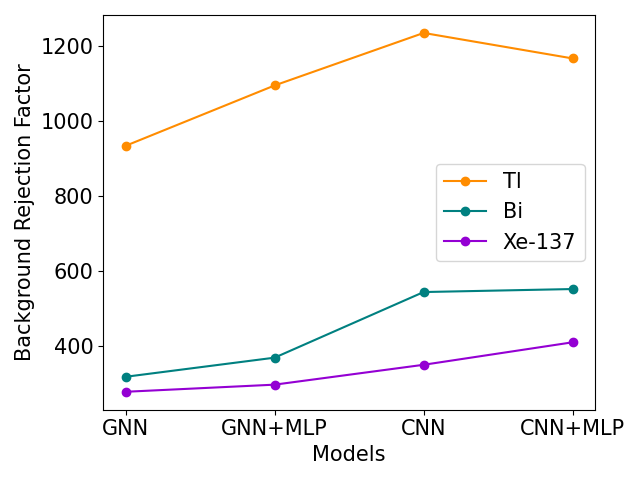

FileNotFoundError: [Errno 2] No such file or directory: '/Users/krishan.mistry/OneDrive - UT Arlington/Projects/Atmospheric TPC/ATPC Paper Updated/ML_Rej.pdf'

In [27]:
GNN_Rej = [934, 318, 278]
GNN_Eff = [99.89, 99.69, 99.64]

GNN_Rej_MLP = [1095, 369, 297]
GNN_Eff_MLP = [99.91, 99.73, 99.66]

CNN_Rej = [1235, 544, 350]
CNN_Eff = [99.92, 99.82, 99.71]

CNN_Rej_MLP = [1167, 552, 410]
CNN_Eff_MLP = [99.90, 99.79, 99.66]

labels = ["Tl", "Bi", "Xe-137"]

models = ["GNN", "GNN+MLP", "CNN", "CNN+MLP"]


plt.figure()

plt.plot(models, [GNN_Rej[0], GNN_Rej_MLP[0], CNN_Rej[0], CNN_Rej_MLP[0]], label = labels[0], marker='o', color = "DarkOrange")
plt.plot(models, [GNN_Rej[1], GNN_Rej_MLP[1], CNN_Rej[1], CNN_Rej_MLP[1]], label = labels[1], marker='o', color = "Teal")
plt.plot(models, [GNN_Rej[2], GNN_Rej_MLP[2], CNN_Rej[2], CNN_Rej_MLP[2]], label = labels[2], marker='o', color = "darkviolet")
plt.ylabel("Background Rejection Factor", fontsize=15)
plt.xlabel("Models", fontsize=15)
plt.legend(fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.tight_layout()
plt.show()
plt.savefig(f"/Users/krishan.mistry/OneDrive - UT Arlington/Projects/Atmospheric TPC/ATPC Paper Updated/ML_Rej.pdf")


plt.figure()

plt.plot(models, [GNN_Eff[0], GNN_Eff_MLP[0], CNN_Eff[0], CNN_Eff_MLP[0]], label = labels[0], marker='o', color = "DarkOrange")
plt.plot(models, [GNN_Eff[1], GNN_Eff_MLP[1], CNN_Eff[1], CNN_Eff_MLP[1]], label = labels[1], marker='o', color = "Teal")
plt.plot(models, [GNN_Eff[2], GNN_Eff_MLP[2], CNN_Eff[2], CNN_Eff_MLP[2]], label = labels[2], marker='o', color = "darkviolet")
plt.ylabel("Background Rejection [%]", fontsize=15)
plt.xlabel("Models", fontsize=15)
plt.legend(fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.tight_layout()
plt.show()


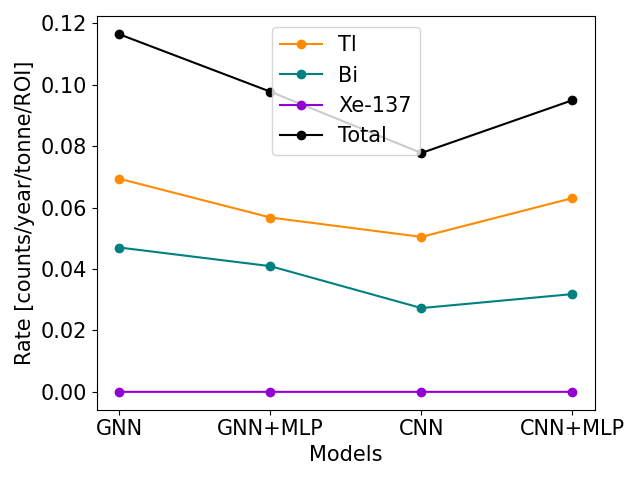

In [19]:
# Now lets convert the factors to a total background rate for 0nubb
Mcu = 201251
sec_in_yr = 3.15e7

Bi_rate = 1.28e-6 * 708/1e8 * sec_in_yr * Mcu * 0.264
Tl_rate = 35.94e-2 * 1.22e-6 * 3153/1e7 * sec_in_yr * Mcu * 0.072
Single_rate = 5827/100000 * 1.4 * 0.078


GNN_EffR =     1-(np.array([99.89, 99.69, 99.64]))/100
GNN_EffR_MLP = 1-(np.array([99.91, 99.73, 99.66]))/100
CNN_EffR =     1-(np.array([99.92, 99.82, 99.71]))/100
CNN_EffR_MLP = 1-(np.array([99.90, 99.79, 99.66]))/100


plt.figure()

plt.plot(models, [GNN_EffR[0]*Tl_rate, GNN_EffR_MLP[0]*Tl_rate, CNN_EffR[0]*Tl_rate, CNN_EffR_MLP[0]*Tl_rate], label = labels[0], marker='o', color = "DarkOrange")
plt.plot(models, [GNN_EffR[1]*Bi_rate, GNN_EffR_MLP[1]*Bi_rate, CNN_EffR[1]*Bi_rate, CNN_EffR_MLP[1]*Bi_rate], label = labels[1], marker='o', color = "Teal")
plt.plot(models, [GNN_EffR[2]*Single_rate, GNN_EffR_MLP[2]*Single_rate, CNN_EffR[2]*Single_rate, CNN_EffR_MLP[2]*Single_rate], label = labels[2], marker='o', color = "darkviolet")

plt.plot(models, [GNN_EffR[0]*Tl_rate + GNN_EffR[1]*Bi_rate + GNN_EffR[2]*Single_rate, GNN_EffR_MLP[0]*Tl_rate + GNN_EffR_MLP[1]*Bi_rate + GNN_EffR_MLP[2]*Single_rate, CNN_EffR[0]*Tl_rate + CNN_EffR[1]*Bi_rate + CNN_EffR[2]*Single_rate, CNN_EffR_MLP[0]*Tl_rate + CNN_EffR_MLP[1]*Bi_rate + CNN_EffR_MLP[2]*Single_rate], label = "Total", marker='o', color = "k")

plt.ylabel("Rate [counts/year/tonne/ROI]", fontsize=15)
plt.xlabel("Models", fontsize=15)
plt.legend(fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.tight_layout()
plt.show()

